In [1]:
## Dia 1 Carga y exploración de datos

# Instalar la librería de UCI
!pip install ucimlrepo

In [2]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

In [3]:
# Cargar el dataset de UCI
auto_mpg = fetch_ucirepo(id=9)

df= pd.concat([auto_mpg.data.features, auto_mpg.data.targets], axis=1)

In [4]:
# Exploración básica
print(df.shape)        # (398, 9)
print(df.dtypes)
print(df.isnull().sum())  # Verás 6 nulls en horsepower
df.describe()

(398, 8)
displacement    float64
cylinders         int64
horsepower      float64
weight            int64
acceleration    float64
model_year        int64
origin            int64
mpg             float64
dtype: object
displacement    0
cylinders       0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
mpg             0
dtype: int64


,displacement,cylinders,horsepower,weight,acceleration,model_year,origin,mpg
count,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,193.425879,5.454774,104.469388,2970.424623,15.568090,76.010050,1.572864,23.514573
std,104.269838,1.701004,38.491160,846.841774,2.757689,3.697627,0.802055,7.815984
min,68.000000,3.000000,46.000000,1613.000000,8.000000,70.000000,1.000000,9.000000
25%,104.250000,4.000000,75.000000,2223.750000,13.825000,73.000000,1.000000,17.500000
50%,148.500000,4.000000,93.500000,2803.500000,15.500000,76.000000,1.000000,23.000000
75%,262.000000,8.000000,126.000000,3608.000000,17.175000,79.000000,2.000000,29.000000
max,455.000000,8.000000,230.000000,5140.000000,24.800000,82.000000,3.000000,46.600000


## El dataset está cargado.
### Lo que podemos ver:
-398 filas en casi todas las columnas, excepto "horsepower" que tiene 392 (Es decir, que tiene 6 datos nulos)
- "Model Year" tiene el mínimo en 70 (Entiendo que 1970), y el máximo 82 (1982)
- "MPG" significa "Millas por galon de gasolina", se refiere al consumo del coche, que su media está en 23.51
- El objetivo se centra en poder predecir el consumo de un coche a partir de sus características

In [5]:
# Reviso si hay duplicados, nulos o tipos de datos incorrectos

# Duplicados
df.duplicated().sum()

# Nulos
df.isnull().sum()

# Tipos de datos correctos
df.dtypes

print("Filas duplicadas:", df.duplicated().sum())
print("\nValores nulos:")
print(df.isnull().sum())
print("\nTipos de datos:")
print(df.dtypes)

Filas duplicadas: 0

Valores nulos:
displacement    0
cylinders       0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
mpg             0
dtype: int64

Tipos de datos:
displacement    float64
cylinders         int64
horsepower      float64
weight            int64
acceleration    float64
model_year        int64
origin            int64
mpg             float64
dtype: object


## Oberservaciones:
- Datos duplicados: Ninguno.
- Como había dicho antes, hay 6 nulos en "Horsepower" Que lo rellenaré con la mediana.
- Todos los tipos de datos a mi parecer son correctos.

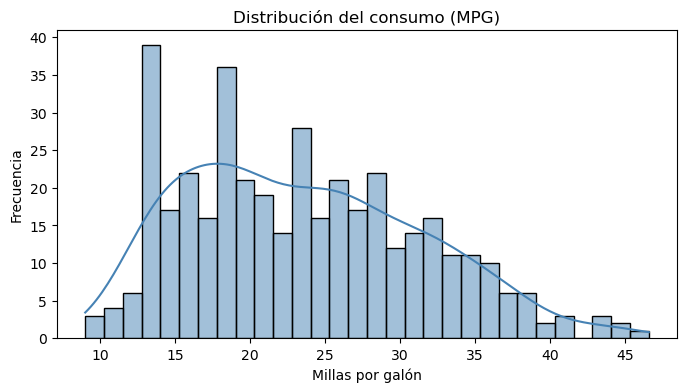

In [6]:
# Visualización de la distribución del mpg (mi variable objetivo)

plt.figure(figsize=(8,4))
sns.histplot(df['mpg'], bins=30, kde=True, color='steelblue')
plt.title('Distribución del consumo (MPG)')
plt.xlabel('Millas por galón')
plt.ylabel('Frecuencia')
plt.show()

## Observaciones:
- La mayoría de coches consumen 13 y 20 MPG (Son ineficientes los coches de los años 70)
- El pico más alto está entre los 13-14 MPG (Muchos coches, muy consumidores)
- Hay pocos coches muy eficientes (35-45 MPG) (Cola larga a la derecha)
- La media (Línea azul), confirma que visualmente la fórmula "describe()"


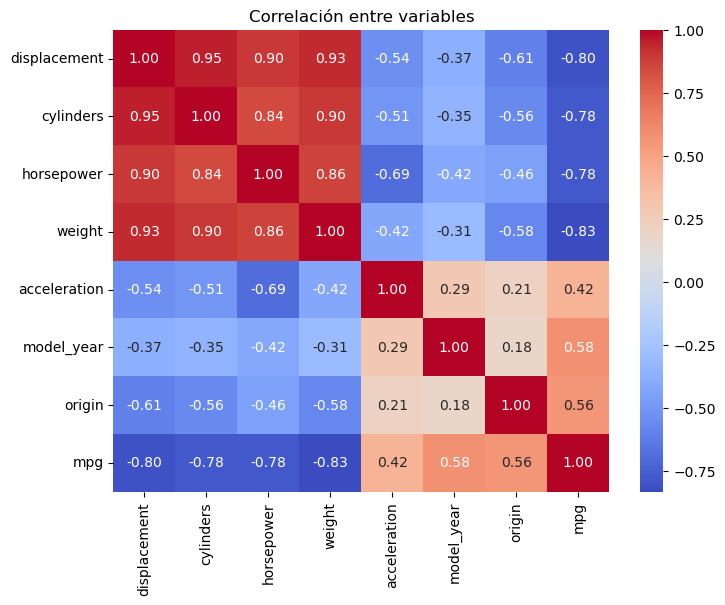

In [7]:
# Mapa de correlación.
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlación entre variables')
plt.show()

## Observaciones:
- Las variables que parecen que afectan más a MPG parecen ser weight, displacement, horsepower y cylinders porque tienen correlaciones muy altas entre sí (o.84-0.95)

C:\Users\erika\AppData\Local\Temp\ipykernel_7540\1634127387.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cylinders', y='mpg', data=df, palette='Set2')


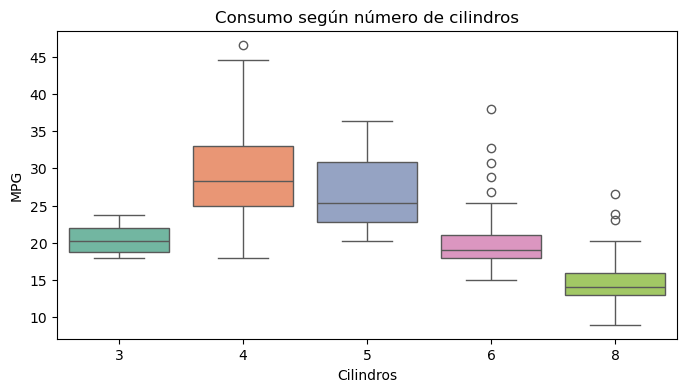

In [8]:
# Visualización de MPG por número de cilindros
plt.figure(figsize=(8,4))
sns.boxplot(x='cylinders', y='mpg', data=df, palette='Set2')
plt.title('Consumo según número de cilindros')
plt.xlabel('Cilindros')
plt.ylabel('MPG')
plt.show()

## Observación:
- La caja más grande es la de 4 cilindros, así que se entiende que hay mucha variedad de coches con 4 cilindros que pueden llegar hasta los 45 MPG.
- La caja más baja es la de 8 cilindros, con un MPG de 15, eso podría decirnos que consumen mucho, aunque hay alguna excepción (outliers)
- Donde hay más outliers, es en los coches de 6 cilindros

C:\Users\erika\AppData\Local\Temp\ipykernel_7540\3297846237.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(x='model_year', y='mpg', data=df, estimator='mean', ci=None, color='green')


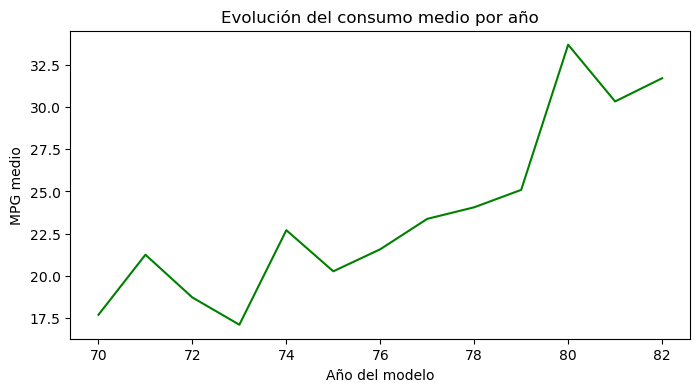

In [9]:
# Evolución del consumo por año
plt.figure(figsize=(8,4))
sns.lineplot(x='model_year', y='mpg', data=df, estimator='mean', ci=None, color='green')
plt.title('Evolución del consumo medio por año')
plt.xlabel('Año del modelo')
plt.ylabel('MPG medio')
plt.show()

# Observaciones:
- En 1970, los coches consumían poco (17-18MPG)
- Cada año los coches se vuelven más eficientes.
- El pico más grande lo vemos en 1980, que empiezan a consumir más de 32,5MPG
- Buscando información de por qué hay ese pico tan grande, fue porque huno una crisis de petróleo a nivel mundial entre los años 1973 y 1979, así que en 1980, los fabricantes tuvieron que empezar a hacer coches mucho más eficientes.

In [10]:
### Limpieza, Encoding y Feature Engineering
# Trartar los 6 nulos en horsepower. Voy a imputar con la mediana.
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')
df['horsepower'] = df['horsepower'].fillna(df['horsepower'].median())

# Verificar que ya no hay nulos
print(df.isnull().sum())

displacement    0
cylinders       0
horsepower      0
weight          0
acceleration    0
model_year      0
origin          0
mpg             0
dtype: int64


In [11]:
# Encoding. Convetir 'origin' a variables dummy
# origin es 1=USA, 2=Europa, 3=Japón
# Lo convertimos en 3 columnas binarias
df = pd.get_dummies(df, columns=['origin'], drop_first=False)

# Verificar resultado
print(df.columns.tolist())
df.head()

['displacement', 'cylinders', 'horsepower', 'weight', 'acceleration', 'model_year', 'mpg', 'origin_1', 'origin_2', 'origin_3']


,displacement,cylinders,horsepower,weight,acceleration,model_year,mpg,origin_1,origin_2,origin_3
0,307.0,8,130.0,3504,12.0,70,18.0,True,False,False
1,350.0,8,165.0,3693,11.5,70,15.0,True,False,False
2,318.0,8,150.0,3436,11.0,70,18.0,True,False,False
3,304.0,8,150.0,3433,12.0,70,16.0,True,False,False
4,302.0,8,140.0,3449,10.5,70,17.0,True,False,False


In [12]:
# Feature Engineering. Crear una nuevas variables.
# Ratio potencia/peso → coches potentes pero ligeros son más eficientes
df['power_to_weight'] = df['horsepower'] / df['weight']

# Cilindrada por cilindro → tamaño medio de cada cilindro
df['displacement_per_cylinder'] = df['displacement'] / df['cylinders']

# Ver el resultado
df.head()

,displacement,cylinders,horsepower,weight,acceleration,model_year,mpg,origin_1,origin_2,origin_3,power_to_weight,displacement_per_cylinder
0,307.0,8,130.0,3504,12.0,70,18.0,True,False,False,0.037100,38.375
1,350.0,8,165.0,3693,11.5,70,15.0,True,False,False,0.044679,43.750
2,318.0,8,150.0,3436,11.0,70,18.0,True,False,False,0.043655,39.750
3,304.0,8,150.0,3433,12.0,70,16.0,True,False,False,0.043694,38.000
4,302.0,8,140.0,3449,10.5,70,17.0,True,False,False,0.040591,37.750


In [13]:
#Verificación final. Comprobar que todo está bien.
print("Shape:", df.shape)
print("\nColumnas:", df.columns.tolist())
print("\nNulos:", df.isnull().sum().sum())
df.describe()

Shape: (398, 12)

Columnas: ['displacement', 'cylinders', 'horsepower', 'weight', 'acceleration', 'model_year', 'mpg', 'origin_1', 'origin_2', 'origin_3', 'power_to_weight', 'displacement_per_cylinder']

Nulos: 0


,displacement,cylinders,horsepower,weight,acceleration,model_year,mpg,power_to_weight,displacement_per_cylinder
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,193.425879,5.454774,104.304020,2970.424623,15.568090,76.010050,23.514573,0.034892,33.365054
std,104.269838,1.701004,38.222625,846.841774,2.757689,3.697627,7.815984,0.005982,8.687268
min,68.000000,3.000000,46.000000,1613.000000,8.000000,70.000000,9.000000,0.020557,17.000000
25%,104.250000,4.000000,76.000000,2223.750000,13.825000,73.000000,17.500000,0.030851,24.625000
50%,148.500000,4.000000,93.500000,2803.500000,15.500000,76.000000,23.000000,0.034285,33.333333
75%,262.000000,8.000000,125.000000,3608.000000,17.175000,79.000000,29.000000,0.038168,38.916667
max,455.000000,8.000000,230.000000,5140.000000,24.800000,82.000000,46.600000,0.072910,56.875000


In [14]:
# Feature Scaling - StandardScaler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Separar features y target
X = df.drop(columns=['mpg'])
y = df['mpg']

# Train/Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
# Escalar solo las columnas numéricas continuas (no las binarias de origin)
cols_to_scale = ['displacement', 'cylinders', 'horsepower', 'weight',
                 'acceleration', 'model_year', 'power_to_weight',
                 'displacement_per_cylinder']

scaler = StandardScaler()
X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("\nEjemplo de datos escalados:")
X_train.head()

X_train shape: (318, 11)
X_test shape: (80, 11)

Ejemplo de datos escalados:


,displacement,cylinders,horsepower,weight,acceleration,model_year,origin_1,origin_2,origin_3,power_to_weight,displacement_per_cylinder
3,1.090196,1.527188,1.265821,0.552826,-1.319334,-1.696667,True,False,False,1.511614,0.547229
18,-0.922996,-0.850515,-0.408635,-0.999667,-0.413182,-1.696667,False,False,True,1.116362,-1.040666
376,-0.981350,-0.850515,-0.948782,-1.124772,0.927922,1.638975,False,False,True,-0.168630,-1.213890
248,-0.981350,-0.850515,-1.164840,-1.392854,0.275493,0.527094,False,False,True,-0.209652,-1.213890
177,-0.747936,-0.850515,-0.219583,-0.327675,-0.231952,-0.306816,False,True,False,0.111037,-0.520991


In [15]:
# KNN Regressor
## Día 3 - Modelos

from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_squared_error

knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

print("=== KNN Regressor ===")
print("R²:", round(r2_score(y_test, y_pred_knn), 4))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, y_pred_knn)), 4))

=== KNN Regressor ===
R²: 0.8907
RMSE: 2.4244


In [16]:
# Linear Regression:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("=== Linear Regression ===")
print("R²:", round(r2_score(y_test, y_pred_lr), 4))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, y_pred_lr)), 4))

=== Linear Regression ===
R²: 0.8746
RMSE: 2.5963


In [17]:
# Decision Tree Regressor:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print("=== Decision Tree Regressor ===")
print("R²:", round(r2_score(y_test, y_pred_dt), 4))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, y_pred_dt)), 4))

=== Decision Tree Regressor ===
R²: 0.8142
RMSE: 3.1603


In [18]:
# Comparación de modelos
resultados = pd.DataFrame({
    'Modelo': ['KNN Regressor', 'Linear Regression', 'Decision Tree'],
    'R²': [round(r2_score(y_test, y_pred_knn), 4),
           round(r2_score(y_test, y_pred_lr), 4),
           round(r2_score(y_test, y_pred_dt), 4)],
    'RMSE': [round(np.sqrt(mean_squared_error(y_test, y_pred_knn)), 4),
             round(np.sqrt(mean_squared_error(y_test, y_pred_lr)), 4),
             round(np.sqrt(mean_squared_error(y_test, y_pred_dt)), 4)]
})

print(resultados.to_string(index=False))

           Modelo     R²   RMSE
    KNN Regressor 0.8907 2.4244
Linear Regression 0.8746 2.5963
    Decision Tree 0.8142 3.1603


### Observaciones:
## Resultados Día 3 - Comparación de Modelos

| Modelo | R² | RMSE |
|---|---|---|
| KNN Regressor | 0.8907 | 2.4244 |
| Linear Regression | 0.8746 | 2.5963 |
| Decision Tree | 0.8142 | 3.1603 |

### Observaciones:
- El mejor modelo hasta ahora es **KNN Regressor** con un R² de 0.89, lo que significa que explica el 89% de la variación en el consumo.
- **Linear Regression** tiene resultados similares (R² 0.87), lo cual tiene sentido ya que las variables tienen una correlación bastante lineal con el MPG, como vimos en el heatmap del Día 1.
- **Decision Tree** es el peor de los tres (R² 0.81), ya que sin ajuste de hiperparámetros tiende a sobreajustarse (overfitting).

In [19]:
## Día 4 - Modelos Avanzados

from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("=== Random Forest Regressor ===")
print("R²:", round(r2_score(y_test, y_pred_rf), 4))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, y_pred_rf)), 4))

=== Random Forest Regressor ===
R²: 0.9223
RMSE: 2.0443


In [20]:
# GridSearch para optimizar hiperparámetros del Random Forest
from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(RandomForestRegressor(random_state=42), 
                    params, cv=5, scoring='r2')
grid.fit(X_train, y_train)

print("Mejores parámetros:", grid.best_params_)
print("Mejor R² en CV:", round(grid.best_score_, 4))

Mejores parámetros: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
Mejor R² en CV: 0.8468


In [21]:
# Modelo final con los mejores parámetros
rf_best = RandomForestRegressor(max_depth=10, min_samples_split=2, 
                                 n_estimators=200, random_state=42)
rf_best.fit(X_train, y_train)
y_pred_rf_best = rf_best.predict(X_test)

print("=== Random Forest Optimizado ===")
print("R²:", round(r2_score(y_test, y_pred_rf_best), 4))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, y_pred_rf_best)), 4))

=== Random Forest Optimizado ===
R²: 0.9222
RMSE: 2.0449


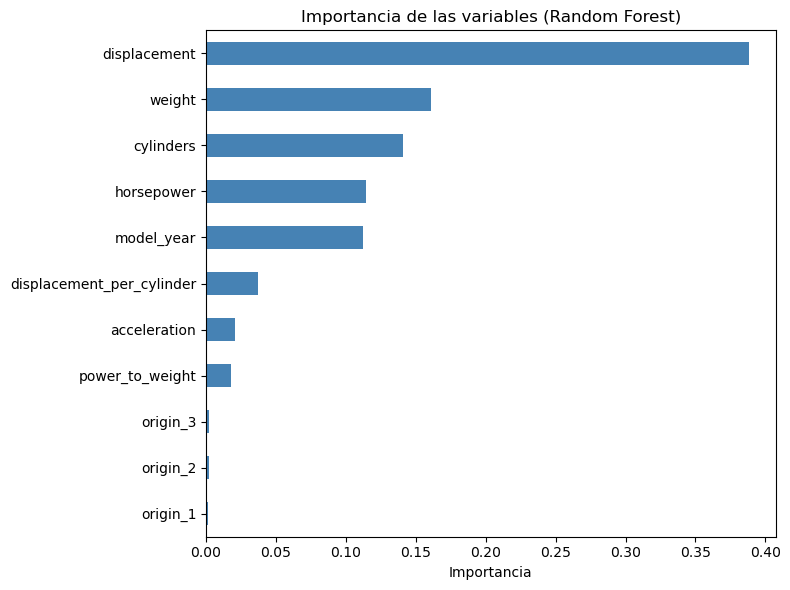

In [22]:
# Feature Importance - qué variables influyen más en el consumo
importances = pd.Series(rf_best.feature_importances_, index=X_train.columns)
importances_sorted = importances.sort_values()

plt.figure(figsize=(8,6))
importances_sorted.plot(kind='barh', color='steelblue')
plt.title('Importancia de las variables (Random Forest)')
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()

In [23]:
# Resumen final de todos los modelos
resultados_final = pd.DataFrame({
    'Modelo': ['KNN Regressor', 'Linear Regression', 'Decision Tree', 
               'Random Forest', 'Random Forest Optimizado'],
    'R²': [round(r2_score(y_test, y_pred_knn), 4),
           round(r2_score(y_test, y_pred_lr), 4),
           round(r2_score(y_test, y_pred_dt), 4),
           round(r2_score(y_test, y_pred_rf), 4),
           round(r2_score(y_test, y_pred_rf_best), 4)],
    'RMSE': [round(np.sqrt(mean_squared_error(y_test, y_pred_knn)), 4),
             round(np.sqrt(mean_squared_error(y_test, y_pred_lr)), 4),
             round(np.sqrt(mean_squared_error(y_test, y_pred_dt)), 4),
             round(np.sqrt(mean_squared_error(y_test, y_pred_rf)), 4),
             round(np.sqrt(mean_squared_error(y_test, y_pred_rf_best)), 4)]
})

print(resultados_final.to_string(index=False))

                  Modelo     R²   RMSE
           KNN Regressor 0.8907 2.4244
       Linear Regression 0.8746 2.5963
           Decision Tree 0.8142 3.1603
           Random Forest 0.9223 2.0443
Random Forest Optimizado 0.9222 2.0449


## Resultados Día 4 - Modelos Avanzados

### Tabla comparativa final:
| Modelo | R² | RMSE |
|---|---|---|
| KNN Regressor | 0.8907 | 2.4244 |
| Linear Regression | 0.8746 | 2.5963 |
| Decision Tree | 0.8142 | 3.1603 |
| Random Forest | 0.9223 | 2.0443 |
| Random Forest Optimizado | 0.9222 | 2.0449 |

### Observaciones:
- El **Random Forest** es el mejor modelo con R² de 0.92, mejorando todos los modelos del Día 3.
- El GridSearch confirmó que los parámetros óptimos son max_depth=10, n_estimators=200, aunque la mejora respecto al modelo base es mínima.
- Según el Feature Importance, **displacement** es la variable más influyente, seguida de weight, cylinders y horsepower.
- El origen del coche (USA, Europa, Japón) apenas influye en el consumo una vez controladas las características técnicas.
- El modelo final se equivoca de media **2.04 MPG**, lo cual es un resultado muy bueno para este dataset.